# M4.Ex1: Housing Prices Model (PyCaret)

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M6/exercises/ex1_pycaret_regression.ipynb)

## Exercise

Your task is to follow the steps outlined here, and apply them on the **California Housing Dataset** below:

- [**🚀 Regression**](https://pycaret.gitbook.io/docs/get-started/quickstart#regression)
    - Setup
    - Compare Models
    - Analyze Model
    - Predictions
    - Save the model

## California Housing Prices Dataset


Find and download the dataset from Kaggle at [California Housing Dataset](https://www.kaggle.com/datasets/dhirajnirne/california-housing-data).

According to [keras.io](https://keras.io/api/datasets/california_housing/):

> This dataset was obtained from the StatLib repository.
>
> It's a continuous regression dataset with 20,640 samples with 8 features each.
>
> The target variable is a scalar: the median house value for California districts, in dollars.
>
> The 8 input features are the following:
>
> - MedInc: median income in block group
> - HouseAge: median house age in block group
> - AveRooms: average number of rooms per household
> - AveBedrms: average number of bedrooms per household
> - Population: block group population
> - AveOccup: average number of household members
> - Latitude: block group latitude
> - Longitude: block group longitude
>
> This dataset was derived from the 1990 U.S. census, using one row per census block group. A block group is the smallest geographical unit for which the U.S. Census Bureau publishes sample data (a block group typically has a population of 600 to 3,000 people).
>
> A household is a group of people residing within a home. Since the average number of rooms and bedrooms in this dataset are provided per household, these columns may take surprisingly large values for block groups with few households and many empty houses, such as vacation resorts.

### Load the data

In [5]:
import pandas as pd


In [8]:
df=pd.read_csv("california_housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [1]:
!pip install pycaret

In [22]:

from pycaret.datasets import get_data
data = get_data('california_housing')

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**Task**: Your model should learn from this data and be able to predict the median housing price (`median_house_value`) in any district, given all the other metrics.

Please read the above dataset description to understand what the features mean.

In [23]:
from pycaret.regression import *
s = setup(data, target = 'median_house_value', session_id = 123)

,Description,Value
0,Session id,123
1,Target,median_house_value
2,Target type,Regression
3,Original data shape,"(20640, 10)"
4,Transformed data shape,"(20640, 14)"
5,Transformed train set shape,"(14447, 14)"
6,Transformed test set shape,"(6193, 14)"
7,Numeric features,8
8,Categorical features,1
9,Rows with missing values,1.0%


In [25]:
from pycaret.regression import RegressionExperiment
s = RegressionExperiment()
s.setup(data, target = 'median_house_value', session_id = 123)

,Description,Value
0,Session id,123
1,Target,median_house_value
2,Target type,Regression
3,Original data shape,"(20640, 10)"
4,Transformed data shape,"(20640, 14)"
5,Transformed train set shape,"(14447, 14)"
6,Transformed test set shape,"(6193, 14)"
7,Numeric features,8
8,Categorical features,1
9,Rows with missing values,1.0%


In [26]:
best = compare_models()

best = s.compare_models()


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,32446.5243,2352506625.5720,48484.5478,0.8231,0.2376,0.1806,0.5890
rf,Random Forest Regressor,32601.1401,2500102516.8196,49989.2760,0.8121,0.2415,0.1817,10.7550
et,Extra Trees Regressor,35279.0180,2805036753.3820,52947.4818,0.7892,0.2522,0.1955,4.3230
gbr,Gradient Boosting Regressor,39009.2448,3150819000.1502,56118.7995,0.7633,0.2736,0.2186,2.6160
lr,Linear Regression,50154.1376,4757779475.9005,68960.1376,0.6429,0.3811,0.2885,0.9550
lasso,Lasso Regression,50154.5348,4757787550.5767,68960.2055,0.6429,0.3811,0.2885,0.1450
ridge,Ridge Regression,50155.4032,4757762702.3264,68960.0498,0.6429,0.3810,0.2885,0.0660
llar,Lasso Least Angle Regression,50154.5079,4757786154.0176,68960.1951,0.6429,0.3811,0.2885,0.1120
br,Bayesian Ridge,50167.2546,4759928809.4993,68976.0109,0.6428,0.3809,0.2887,0.0790
lar,Least Angle Regression,50318.6460,4895005267.5488,69952.2585,0.6326,0.4105,0.2860,0.0660


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,32446.5243,2352506625.5720,48484.5478,0.8231,0.2376,0.1806,1.0210
rf,Random Forest Regressor,32601.1401,2500102516.8196,49989.2760,0.8121,0.2415,0.1817,10.3730
et,Extra Trees Regressor,35279.0180,2805036753.3820,52947.4818,0.7892,0.2522,0.1955,4.3310
gbr,Gradient Boosting Regressor,39009.2448,3150819000.1502,56118.7995,0.7633,0.2736,0.2186,2.7330
lr,Linear Regression,50154.1376,4757779475.9005,68960.1376,0.6429,0.3811,0.2885,0.0660
lasso,Lasso Regression,50154.5348,4757787550.5767,68960.2055,0.6429,0.3811,0.2885,0.2220
ridge,Ridge Regression,50155.4032,4757762702.3264,68960.0498,0.6429,0.3810,0.2885,0.1120
llar,Lasso Least Angle Regression,50154.5079,4757786154.0176,68960.1951,0.6429,0.3811,0.2885,0.0700
br,Bayesian Ridge,50167.2546,4759928809.4993,68976.0109,0.6428,0.3809,0.2887,0.0750
lar,Least Angle Regression,50318.6460,4895005267.5488,69952.2585,0.6326,0.4105,0.2860,0.0690


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

In [27]:
print(best)

LGBMRegressor(n_jobs=-1, random_state=123)


In [28]:
s.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

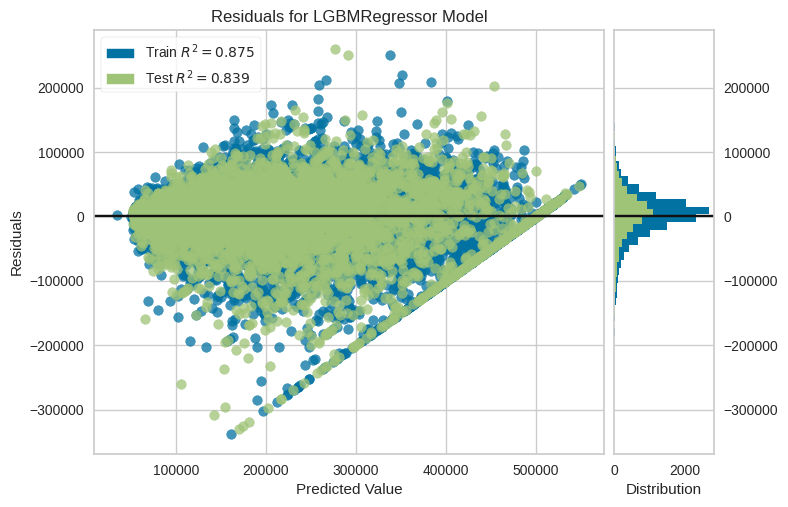

In [31]:
s.plot_model(best, plot = 'residuals')

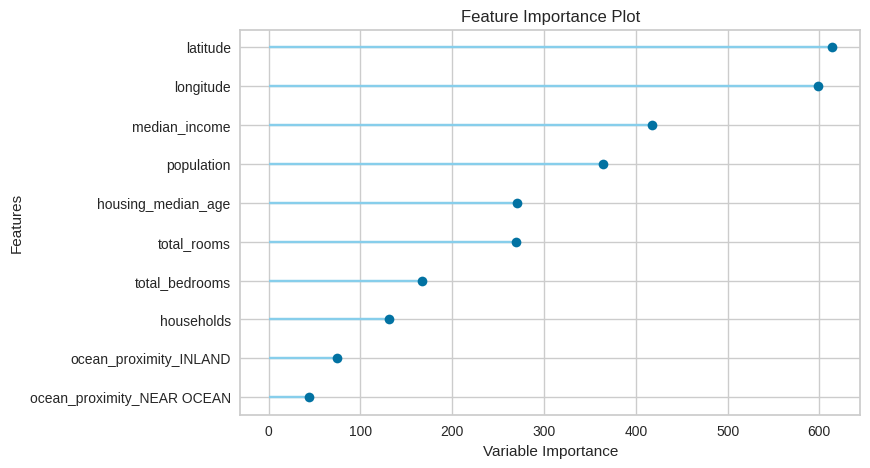

In [32]:
s.plot_model(best, plot = 'feature')

In [33]:
predictions = s.predict_model(best, data=data)
predictions.head()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,28997.8123,1804392628.6976,42478.1430,0.8645,0.2154,0.1643


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,prediction_label
0,-122.230003,37.880001,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY,452600.0,412646.992698
1,-122.220001,37.860001,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY,358500.0,421506.847007
2,-122.239998,37.849998,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY,352100.0,415404.138010
3,-122.250000,37.849998,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY,341300.0,344059.284174
4,-122.250000,37.849998,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY,342200.0,275169.000685


In [34]:
s.save_model(best, 'my_best_pipeline')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['longitude', 'latitude',
                                              'housing_median_age',
                                              'total_rooms', 'total_bedrooms',
                                              'population', 'households',
                                              'median_income'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['ocean_proximity'],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('onehot_encoding',
                  TransformerWrapper(include=['ocean_proximity'],
                                     transformer=OneHotEncoder(cols=['ocean_proximity'],
                                                               handle_missing='return_nan',
              